# Cost Plan Estimation with Machine Learning
**Author:** Atul Iwale · **Project 13** of the AEC Fieldwork portfolio

**Business question:** at feasibility stage, what will this building cost per square metre, and how confident can we be?

Quantity surveyors usually estimate early costs with a *coefficient method*: a base rate for the building type, multiplied by coefficients for specification and location. I built exactly that kind of automation earlier in my career. This notebook tests whether machine learning can beat it, using 1,806 completed building projects across 15 Indian cities (synthetic data, patterned on real cost-plan structures).

**Contents**
1. Load and audit the data
2. Clean it (duplicates, spellings, unit errors, missing values)
3. Explore what drives cost
4. Feature engineering (joins to location and material price index)
5. Time-based train/test split
6. Baseline: the coefficient method
7. Models: Linear, Ridge, Decision Tree, Random Forest, XGBoost, Neural Network (MLP)
8. Compare on unseen 2024–2025 projects
9. Explain the model (feature importance, SHAP)
10. Estimate ranges (P10–P90) with quantile models
11. Error analysis
12. Apply to the 21 building projects in my portfolio
13. Export the model for the web app

In [1]:
import warnings, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb, shap
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
RANDOM_STATE = 42
DATA = '../data/13_Cost_Plan_Estimation.xlsx'

## 1. Load and audit the data

In [2]:
raw  = pd.read_excel(DATA, sheet_name='fact_building_cost')
loc  = pd.read_excel(DATA, sheet_name='dim_location')
mat  = pd.read_excel(DATA, sheet_name='material_price_index')
port = pd.read_excel(DATA, sheet_name='portfolio_building_projects')
print(f'fact_building_cost: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
print(f'dim_location: {len(loc)} cities | material_price_index: {len(mat)} months | portfolio projects: {len(port)}')
raw.head()

fact_building_cost: 1,806 rows x 18 columns
dim_location: 15 cities | material_price_index: 96 months | portfolio projects: 21


,project_id,city,building_type,spec_grade,built_up_area_sqm,floors_above_ground,basements,structure_system,foundation_type,soil_type,facade_type,hvac_system,green_rating,site_condition,contract_type,start_date,planned_duration_months,total_project_cost_inr
0,HP0740,Bengaluru,Warehouse / Logistics,Premium,32745,2,0,PEB steel,Isolated footing,Soft clay,Glass curtain wall,Central VRF,Not certified,Greenfield,Lump sum,2025-05-23,19.0,900996000
1,HP0202,Chennai,Data Centre,Premium,26598,6,1,RCC frame,Raft,NaN,ACP cladding,Central chilled water,LEED Gold,Urban infill,EPC,2021-09-11,22.0,2983588000
2,HP1467,Nagpur,Warehouse / Logistics,Economy,523653,2,0,PEB steel,Isolated footing,Soft clay,Brick & plaster,Split units,NaN,Greenfield,EPC,2020-03-10,16.0,422237000
3,HP1358,Pune,Mid-Segment Residential,Standard,24386,28,0,RCC frame,Pile,Medium clay,Brick & plaster,None / ventilation only,Not certified,Greenfield,Item rate,2020-07-22,27.0,718668000
4,HP1113,Nagpur,Premium Residential,Premium,56939,25,2,RCC shear wall (aluminium formwork),Pile,Medium clay,Brick & plaster,Split units,NaN,Urban infill,Item rate,2020-06-07,39.0,1865997000


In [3]:
audit = pd.DataFrame({
    'missing': raw.isna().sum(),
    'missing_%': (raw.isna().mean()*100).round(1),
    'unique': raw.nunique()})
print('Exact duplicate rows:', raw.duplicated().sum())
print('Duplicate project_id:', raw.project_id.duplicated().sum())
print('Cities not in dim_location:', sorted(set(raw.city) - set(loc.city)))
print('Building-type spellings:', raw.building_type.nunique())
audit[audit.missing > 0]

Exact duplicate rows: 6
Duplicate project_id: 6
Cities not in dim_location: ['Bangalore', 'Bombay ', 'Gurgaon']
Building-type spellings: 17


,missing,missing_%,unique
soil_type,100,5.5,5
facade_type,74,4.1,4
green_rating,68,3.8,4
planned_duration_months,30,1.7,49


## 2. Clean the data
The audit shows the usual problems of real cost databases: 6 duplicate rows, legacy city names (Bangalore, Gurgaon, Bombay), inconsistent upper-case building types, missing soil reports, and missing facade/green/duration fields. I also check for **unit errors**: area typed in square feet instead of square metres makes the rate look about 10.8 times too low.

In [4]:
df = raw.drop_duplicates().copy()
df['city'] = df.city.str.strip().replace({'Bangalore': 'Bengaluru', 'Gurgaon': 'Gurugram', 'Bombay': 'Mumbai'})
df['building_type'] = df.building_type.str.strip().str.title().str.replace('Mid-Segment', 'Mid-Segment')
type_fix = {t.title(): t for t in ['Affordable Housing','Mid-Segment Residential','Premium Residential','Commercial Office',
            'Retail Mall','Hospital','School / Institutional','Warehouse / Logistics','Industrial Plant','Data Centre']}
df['building_type'] = df.building_type.map(lambda t: type_fix.get(t, t))
df['start_date'] = pd.to_datetime(df.start_date)
df['rate'] = df.total_project_cost_inr / df.built_up_area_sqm

# Unit errors: rate far below the median of its building type -> area was entered in sq ft
ratio = df.rate / df.groupby('building_type').rate.transform('median')
unit_err = ratio < 0.25
print('Suspected sq-ft entries:', unit_err.sum(), '| ratio range', ratio[unit_err].round(3).min(), '-', ratio[unit_err].round(3).max())
df.loc[unit_err, 'built_up_area_sqm'] = (df.loc[unit_err, 'built_up_area_sqm'] / 10.7639).round(0)
df['rate'] = df.total_project_cost_inr / df.built_up_area_sqm
ratio2 = df.rate / df.groupby('building_type').rate.transform('median')
print('After correction, rate/type-median range:', ratio2.min().round(2), '-', ratio2.max().round(2))

# Missing values: keep information, don't invent it
df['soil_type'] = df.soil_type.fillna('Not investigated')
df['green_rating'] = df.green_rating.fillna('Not recorded')
df['facade_type'] = df.facade_type.fillna(df.groupby(['building_type','spec_grade']).facade_type.transform(lambda s: s.mode().iat[0]))
df['planned_duration_months'] = df.planned_duration_months.fillna(df.groupby('building_type').planned_duration_months.transform('median'))
print('Clean rows:', len(df), '| remaining missing values:', int(df.isna().sum().sum()))
print('Cities now all in dim_location:', set(df.city) <= set(loc.city), '| building types:', df.building_type.nunique())

Suspected sq-ft entries: 18 | ratio range 0.044 - 0.144
After correction, rate/type-median range: 0.44 - 2.25
Clean rows: 1800 | remaining missing values: 0
Cities now all in dim_location: True | building types: 10


## 3. What drives cost?

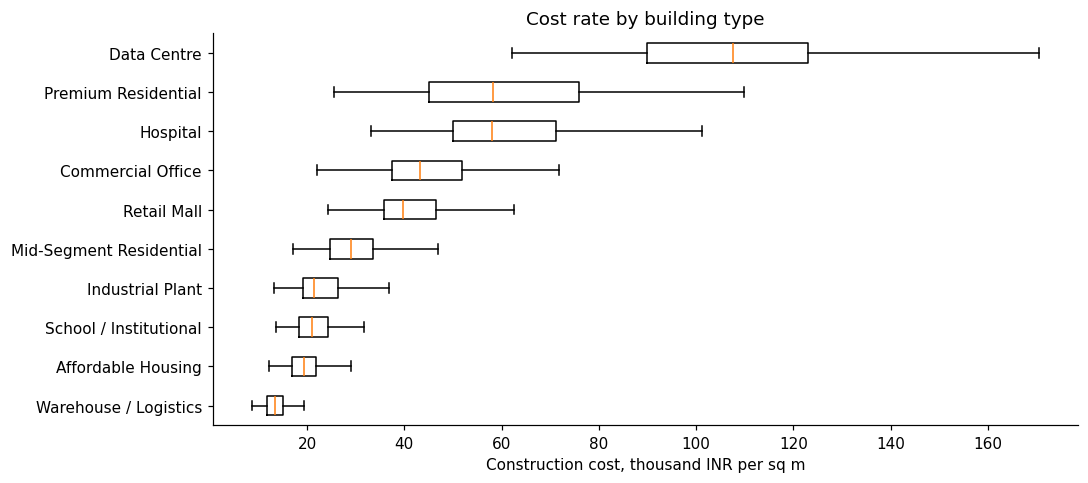

,count,25%,50%,75%
building_type,,,,
Warehouse / Logistics,200.0,11700.0,13400.0,15100.0
Affordable Housing,200.0,16900.0,19400.0,21900.0
School / Institutional,100.0,18300.0,21100.0,24300.0
Industrial Plant,200.0,19100.0,21500.0,26400.0
Mid-Segment Residential,300.0,24700.0,29100.0,33600.0
Retail Mall,100.0,35700.0,39800.0,46500.0
Commercial Office,300.0,37500.0,43300.0,51900.0
Hospital,100.0,49900.0,57900.0,71100.0
Premium Residential,200.0,45100.0,58200.0,75900.0


In [5]:
order = df.groupby('building_type').rate.median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.boxplot([df.loc[df.building_type==t, 'rate']/1000 for t in order], vert=False, labels=order, showfliers=False)
ax.set_xlabel('Construction cost, thousand INR per sq m'); ax.set_title('Cost rate by building type')
plt.tight_layout(); plt.show()
df.groupby('building_type').rate.describe()[['count','25%','50%','75%']].round(-2).sort_values('50%')

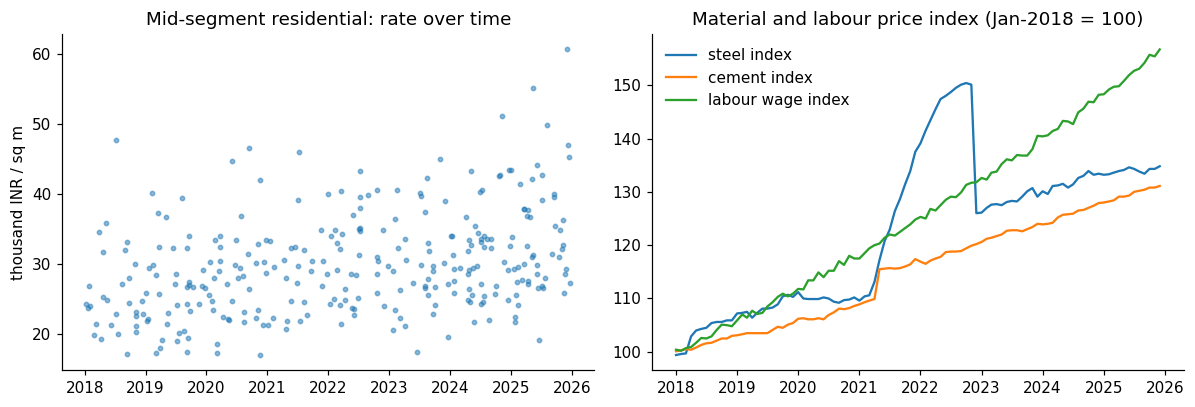

spec_grade,Economy,Standard,Premium,Luxury
building_type,,,,
Affordable Housing,0.82,1.0,1.21,NaN
Commercial Office,0.76,1.0,1.13,1.50
Data Centre,NaN,1.0,1.26,1.49
Hospital,NaN,1.0,1.24,1.69
Industrial Plant,0.88,1.0,1.42,NaN
Mid-Segment Residential,0.79,1.0,1.26,1.64
Premium Residential,NaN,1.0,1.65,1.95
Retail Mall,0.90,1.0,1.14,1.56
School / Institutional,0.83,1.0,1.37,NaN


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
s = df[df.building_type=='Mid-Segment Residential'].sort_values('start_date')
axes[0].scatter(s.start_date, s.rate/1000, s=8, alpha=.5)
axes[0].set_title('Mid-segment residential: rate over time'); axes[0].set_ylabel('thousand INR / sq m')
m2 = mat.copy(); m2['month'] = pd.to_datetime(m2.month)
for c in ['steel_index','cement_index','labour_wage_index']: axes[1].plot(m2.month, m2[c], label=c.replace('_',' '))
axes[1].legend(frameon=False); axes[1].set_title('Material and labour price index (Jan-2018 = 100)')
plt.tight_layout(); plt.show()
spec = df.groupby(['building_type','spec_grade']).rate.median().unstack()[['Economy','Standard','Premium','Luxury']]
(spec.div(spec['Standard'], axis=0)).round(2)

Cost rises over time with the steel, cement and labour indices (note the 2021–22 steel spike), and specification changes the rate by different amounts for different building types. A single fixed coefficient per spec grade will miss that interaction; tree-based models can learn it.

## 4. Feature engineering

In [7]:
def build_features(d):
    d = d.merge(loc[['city','city_tier','seismic_zone']], on='city', how='left')
    d['month'] = pd.to_datetime(d.start_date).dt.strftime('%Y-%m')
    last = mat.iloc[-1]
    d = d.merge(mat, on='month', how='left')
    for c in ['steel_index','cement_index','labour_wage_index']:
        d[c] = d[c].fillna(last[c])          # future starts use the latest published index
    # Composite building cost index: assumed weights 25% steel, 20% cement, 40% labour, 15% other (held flat)
    d['cost_index'] = 0.25*d.steel_index + 0.20*d.cement_index + 0.40*d.labour_wage_index + 0.15*100
    d['log_area'] = np.log(d.built_up_area_sqm)
    return d

CAT = ['city','building_type','spec_grade','structure_system','foundation_type','soil_type','facade_type',
       'hvac_system','green_rating','site_condition','contract_type','city_tier','seismic_zone']
NUM = ['log_area','floors_above_ground','basements','planned_duration_months']

feat = build_features(df)
X_all = pd.get_dummies(feat[CAT], dtype=float).join(feat[NUM])
FEATURES = list(X_all.columns)
print(len(FEATURES), 'model features after one-hot encoding;', int(feat[['city_tier','cost_index']].isna().sum().sum()), 'failed joins')

72 model features after one-hot encoding; 0 failed joins


### Rebasing to constant prices
Quantity surveyors compare projects from different years by first **rebasing** costs to a common date with a cost index. I do the same: the model learns the *real* cost of a building at January-2018 prices, and each estimate is then escalated to its start month with the composite index.

This matters for machine learning too. Tree-based models cannot extrapolate: if 2024 prices are higher than anything in training, a tree can never predict them. Rebasing removes price inflation from the target, so every model only has to learn the building itself.

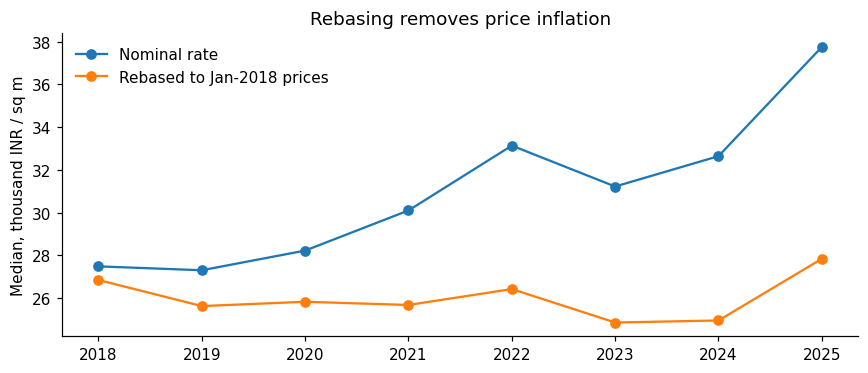

In [8]:
feat['real_rate'] = feat.rate * 100 / feat.cost_index
y_all = np.log(feat.real_rate)               # log target: errors behave like percentages
fig, ax = plt.subplots(figsize=(8, 3.5))
yr = feat.start_date.dt.year
ax.plot(sorted(yr.unique()), feat.groupby(yr).rate.median()/1000, marker='o', label='Nominal rate')
ax.plot(sorted(yr.unique()), feat.groupby(yr).real_rate.median()/1000, marker='o', label='Rebased to Jan-2018 prices')
ax.set_ylabel('Median, thousand INR / sq m'); ax.legend(frameon=False); ax.set_title('Rebasing removes price inflation')
plt.tight_layout(); plt.show()

## 5. Time-based split
A cost model is used on *future* projects, so I split by start date, never randomly:
- **Train:** 2018–2022 starts (model fitting and cross-validation)
- **Calibrate:** 2023 starts (used only to calibrate the P10–P90 range in section 10)
- **Test:** 2024–2025 starts, never seen by any model

Point-estimate models are trained on 2018–2023 combined.

In [9]:
train = feat.start_date < '2024-01-01'
fit_q = feat.start_date < '2023-01-01'; calib = (~fit_q) & train
X_tr, X_te, y_tr = X_all[train], X_all[~train], y_all[train]
rate_te, ci_te = feat.rate[~train].values, feat.cost_index[~train].values
print(f'Train: {train.sum()} (of which calibration year 2023: {calib.sum()}) | Test: {(~train).sum()} projects (2024-2025)')
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)

def to_rate(pred_log, ci):                     # back from log real rate to nominal INR/sq m
    return np.exp(pred_log) * ci / 100
def score(name, pred_log):
    p = to_rate(pred_log, ci_te); err = np.abs(p - rate_te) / rate_te
    return {'model': name, 'MAPE_%': round(100*err.mean(), 2), 'MAE_INR_per_sqm': round(mean_absolute_error(rate_te, p), -1),
            'RMSE_INR_per_sqm': round(mean_squared_error(rate_te, p) ** .5, -1), 'R2': round(r2_score(rate_te, p), 3),
            'within_10%': round(100*(err <= .10).mean(), 1), 'within_20%': round(100*(err <= .20).mean(), 1)}
results, preds = [], {}

Train: 1334 (of which calibration year 2023: 238) | Test: 466 projects (2024-2025)


## 6. Baseline: the coefficient method
This mirrors how early cost plans are often built: **base rate by building type × specification coefficient × city coefficient**, escalated by the cost index. Fitted on the training years as a log-linear model, it is a fair, well-calibrated version of the traditional approach, and every ML model has to beat it.

In [10]:
base_cols = [c for c in FEATURES if c.startswith(('building_type_','spec_grade_','city_')) and not c.startswith('city_tier')]
baseline = LinearRegression().fit(X_tr[base_cols], y_tr)
preds['Coefficient method (baseline)'] = baseline.predict(X_te[base_cols])
results.append(score('Coefficient method (baseline)', preds['Coefficient method (baseline)']))
pd.DataFrame(results)

,model,MAPE_%,MAE_INR_per_sqm,RMSE_INR_per_sqm,R2,within_10%,within_20%
0,Coefficient method (baseline),11.17,5220.0,8400.0,0.917,58.4,83.3


## 7. Machine-learning models
Each model is tuned with 5-fold cross-validation on the training years only.

In [11]:
from sklearn.compose import TransformedTargetRegressor
lin = LinearRegression().fit(X_tr, y_tr); preds['Linear regression'] = lin.predict(X_te)

ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))).fit(X_tr, y_tr)
preds['Ridge regression'] = ridge.predict(X_te)

dt = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                  {'max_depth': [4, 6, 8, 10, 12], 'min_samples_leaf': [5, 10, 20]}, cv=cv,
                  scoring='neg_mean_absolute_error').fit(X_tr, y_tr)
preds['Decision tree'] = dt.predict(X_te)

rf = GridSearchCV(RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
                  {'max_features': [0.3, 0.5], 'min_samples_leaf': [1, 3]}, cv=cv,
                  scoring='neg_mean_absolute_error').fit(X_tr, y_tr)
preds['Random forest'] = rf.predict(X_te)

xg = GridSearchCV(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                   random_state=RANDOM_STATE, n_jobs=4),
                  {'max_depth': [3, 4, 5], 'min_child_weight': [1, 5]}, cv=cv,
                  scoring='neg_mean_absolute_error').fit(X_tr, y_tr)
preds['XGBoost'] = xg.predict(X_te)

# Neural network: inputs and target are standardised; small, well-regularised networks suit ~1,300 rows
mlp = GridSearchCV(TransformedTargetRegressor(
          make_pipeline(StandardScaler(), MLPRegressor(max_iter=5000, early_stopping=True, validation_fraction=0.15,
                                                       n_iter_no_change=50, random_state=RANDOM_STATE)),
          transformer=StandardScaler()),
      {'regressor__mlpregressor__hidden_layer_sizes': [(16,), (32,), (64, 32)], 'regressor__mlpregressor__alpha': [0.3, 1.0, 3.0]},
      cv=cv, scoring='neg_mean_absolute_error').fit(X_tr, y_tr)
preds['Neural network (MLP)'] = mlp.predict(X_te)

# Ensemble: average a linear model and a tree model, which make different kinds of errors
preds['Ensemble (Ridge + XGBoost)'] = (preds['Ridge regression'] + preds['XGBoost']) / 2

for name in ['Linear regression','Ridge regression','Decision tree','Random forest','XGBoost','Neural network (MLP)','Ensemble (Ridge + XGBoost)']:
    results.append(score(name, preds[name]))
print('Best settings -> tree:', dt.best_params_, '| forest:', rf.best_params_, '| xgb:', xg.best_params_)
print('                 mlp:', {k.split('__')[-1]: v for k, v in mlp.best_params_.items()}, '| ridge alpha:', round(ridge[-1].alpha_, 2))

Best settings -> tree: {'max_depth': 12, 'min_samples_leaf': 5} | forest: {'max_features': 0.5, 'min_samples_leaf': 1} | xgb: {'max_depth': 3, 'min_child_weight': 5}
                 mlp: {'alpha': 3.0, 'hidden_layer_sizes': (16,)} | ridge alpha: 1.17


## 8. Results on unseen 2024–2025 projects

In [12]:
res = pd.DataFrame(results).set_index('model').sort_values('MAPE_%')
res

,MAPE_%,MAE_INR_per_sqm,RMSE_INR_per_sqm,R2,within_10%,within_20%
model,,,,,,
Ensemble (Ridge + XGBoost),6.61,2980.0,4560.0,0.975,79.2,96.8
Linear regression,6.64,3020.0,4700.0,0.974,76.8,97.0
Ridge regression,6.64,3010.0,4690.0,0.974,77.3,97.0
Neural network (MLP),6.88,3050.0,4700.0,0.974,76.4,96.4
XGBoost,7.41,3370.0,5080.0,0.970,75.1,96.1
Random forest,9.29,4320.0,6720.0,0.947,61.6,90.6
Decision tree,11.17,5020.0,7750.0,0.929,55.6,83.9
Coefficient method (baseline),11.17,5220.0,8400.0,0.917,58.4,83.3


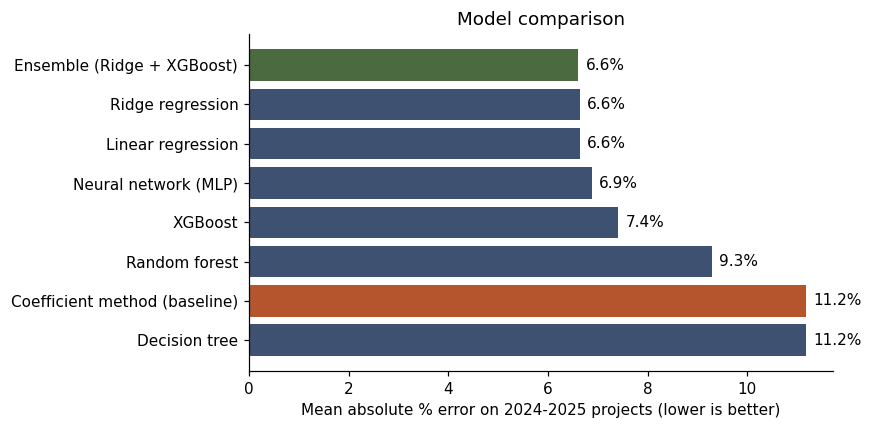

Best: Ensemble (Ridge + XGBoost). Error falls from 11.17% (coefficient method) to 6.61%; estimates within ±10% rise from 58.4% to 79.2% of projects.


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
r = res.sort_values('MAPE_%', ascending=False)
colors = ['#b4552e' if 'baseline' in n else ('#4b6a3f' if n == res.index[0] else '#3f5170') for n in r.index]
ax.barh(r.index, r['MAPE_%'], color=colors)
for i, v in enumerate(r['MAPE_%']): ax.text(v + .15, i, f'{v:.1f}%', va='center')
ax.set_xlabel('Mean absolute % error on 2024-2025 projects (lower is better)'); ax.set_title('Model comparison')
plt.tight_layout(); plt.show()
best = res.index[0]; base = res.loc['Coefficient method (baseline)']
print(f"Best: {best}. Error falls from {base['MAPE_%']}% (coefficient method) to {res.loc[best,'MAPE_%']}%; "
      f"estimates within ±10% rise from {base['within_10%']}% to {res.loc[best,'within_10%']}% of projects.")

**Reading the results**
- Every ML model that uses the full project description beats the coefficient method, because type, spec and city are only part of the story: height, basements, foundations, facade, HVAC and site conditions all move the rate.
- Linear models do very well here. Once costs are rebased and on a log scale, most cost drivers act as percentage uplifts, which is exactly what a log-linear model captures.
- XGBoost adds interactions (for example, specification matters more for premium residential and hospitals). Averaging it with Ridge gives a small further gain: the lowest error, and the most estimates within ±10% of actual.
- The single decision tree is the weakest ML model: it is easy to read but too coarse on its own. The random forest and XGBoost fix that by combining hundreds of trees.
- The neural network needed strong regularisation to work with ~1,300 projects. Neural networks shine with much larger datasets; on small tabular data, well-tuned linear and boosted models are usually as good or better.

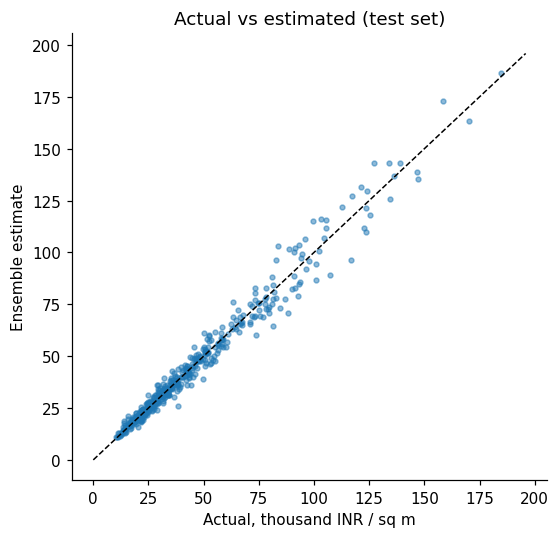

In [14]:
fig, ax = plt.subplots(figsize=(5.2, 5))
p = to_rate(preds['Ensemble (Ridge + XGBoost)'], ci_te)
ax.scatter(rate_te/1000, p/1000, s=10, alpha=.5)
lim = [0, max(rate_te.max(), p.max())/1000*1.05]; ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel('Actual, thousand INR / sq m'); ax.set_ylabel('Ensemble estimate'); ax.set_title('Actual vs estimated (test set)')
plt.tight_layout(); plt.show()

## 9. Explaining the model
A cost plan has to be defensible, so I check *why* the models estimate what they do.

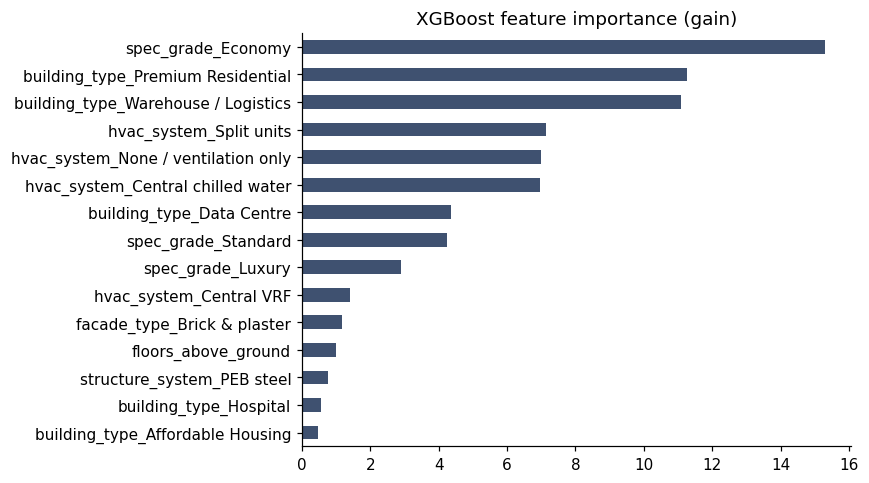

In [15]:
best_xgb = xg.best_estimator_
imp = pd.Series(best_xgb.get_booster().get_score(importance_type='gain')).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 4.5)); imp[::-1].plot.barh(ax=ax, color='#3f5170')
ax.set_title('XGBoost feature importance (gain)'); plt.tight_layout(); plt.show()

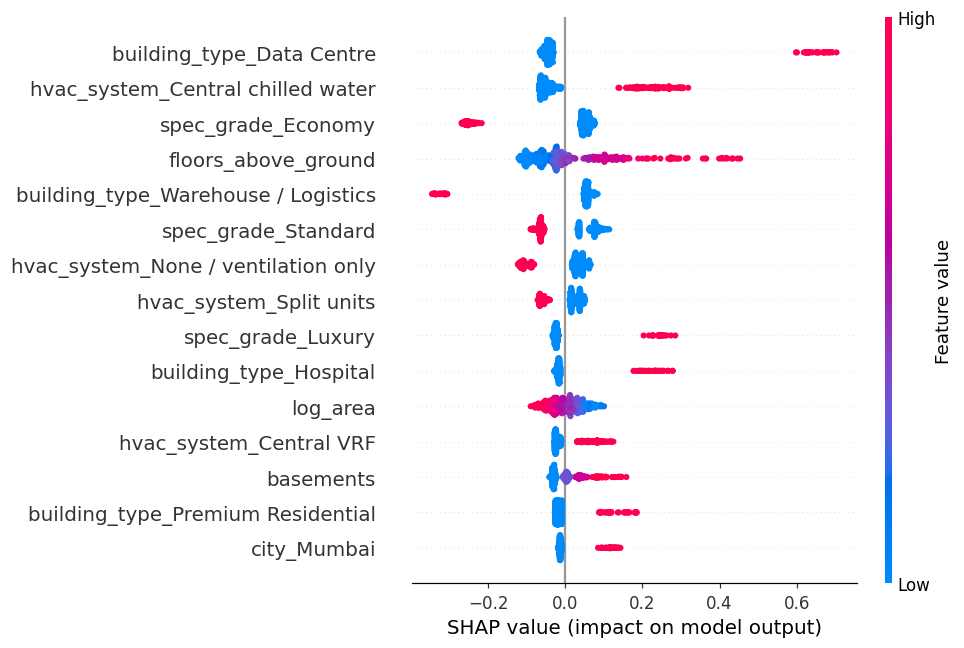

In [16]:
explainer = shap.TreeExplainer(best_xgb)
sv = explainer.shap_values(X_te)
shap.summary_plot(sv, X_te, max_display=15, show=False, plot_size=(9, 6)); plt.tight_layout(); plt.show()

In [17]:
# Ridge coefficients on the original 0/1 scale read directly as % cost uplifts for each option, holding everything else constant
coef = pd.Series(ridge[-1].coef_ / ridge[0].scale_, index=FEATURES)
uplift = ((np.exp(coef) - 1) * 100)
cats = uplift[[c for c in FEATURES if c.startswith(('facade_type_','hvac_system_','foundation_type_','green_rating_','site_condition_'))]]
print('Ridge: % cost uplift for each option (relative to the average option in its group):')
cats.sort_values().round(1).to_frame('uplift_%')

Ridge: % cost uplift for each option (relative to the average option in its group):


,uplift_%
hvac_system_None / ventilation only,-6.7
hvac_system_Split units,-4.4
facade_type_Brick & plaster,-3.3
site_condition_Greenfield,-2.3
green_rating_Not certified,-2.3
green_rating_Not recorded,-1.0
foundation_type_Raft,-0.8
foundation_type_Isolated footing,-0.8
facade_type_ACP cladding,-0.7
site_condition_Urban infill,-0.2


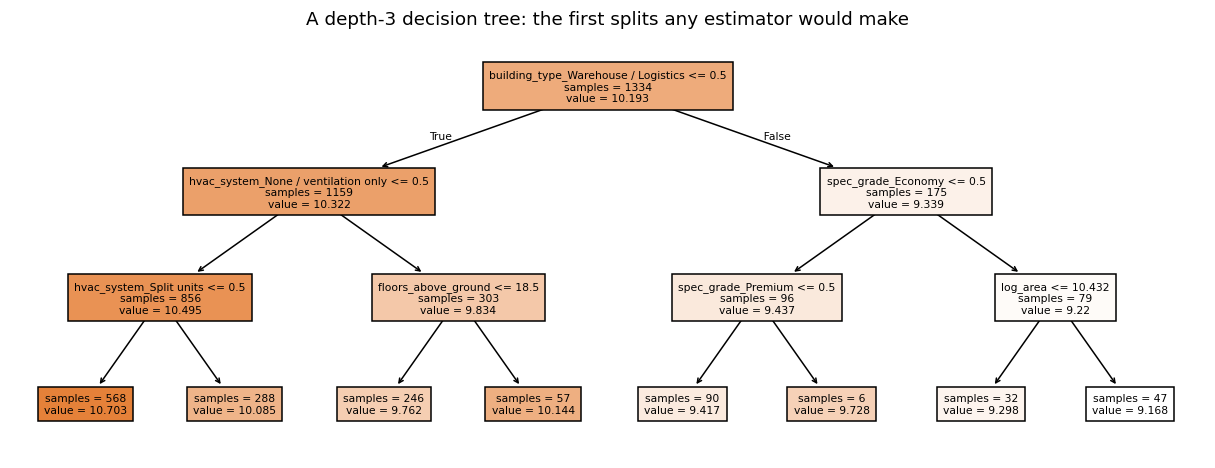

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_tr, y_tr), feature_names=FEATURES,
          filled=True, impurity=False, fontsize=7, ax=ax)
ax.set_title('A depth-3 decision tree: the first splits any estimator would make'); plt.show()

## 10. Estimate ranges, not single numbers
Clients need a range. I train XGBoost with **quantile loss** for P10 and P90 on 2018–2022, then use **conformal calibration** on the 2023 projects: I measure how far actual costs fell outside the raw band and widen it just enough to cover 80% of 2023 projects. The calibrated band is then tested on 2024–2025.

In [19]:
xgb_params = dict(n_estimators=500, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=4,
                  max_depth=xg.best_params_['max_depth'], min_child_weight=xg.best_params_['min_child_weight'])
q10 = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.10, **xgb_params).fit(X_all[fit_q], y_all[fit_q])
q90 = xgb.XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.90, **xgb_params).fit(X_all[fit_q], y_all[fit_q])
lo_c, hi_c, y_c = q10.predict(X_all[calib]), q90.predict(X_all[calib]), y_all[calib].values
scores = np.maximum(lo_c - y_c, y_c - hi_c)                        # conformity score (log scale)
n_c = len(scores); adj = float(np.quantile(scores, min(1, np.ceil((n_c + 1) * 0.80) / n_c)))
lo_raw, hi_raw = to_rate(q10.predict(X_te), ci_te), to_rate(q90.predict(X_te), ci_te)
lo, hi = to_rate(q10.predict(X_te) - adj, ci_te), to_rate(q90.predict(X_te) + adj, ci_te)
cov_raw = ((rate_te >= lo_raw) & (rate_te <= hi_raw)).mean(); coverage = ((rate_te >= lo) & (rate_te <= hi)).mean()
width = np.median((hi - lo) / to_rate(preds['Ensemble (Ridge + XGBoost)'], ci_te))
print(f'Raw quantile band covers {cov_raw:.1%} of 2024-2025 actuals; calibrated band (adjustment {adj:+.3f} log) covers {coverage:.1%} (target 80%).')
print(f'Median calibrated band width: {width:.1%} of the estimate.')

Raw quantile band covers 70.6% of 2024-2025 actuals; calibrated band (adjustment +0.026 log) covers 81.3% (target 80%).
Median calibrated band width: 27.9% of the estimate.


## 11. Where is the model weakest?

In [20]:
t = feat[~train].assign(est=to_rate(preds['Ensemble (Ridge + XGBoost)'], ci_te))
t['abs_err_%'] = (t.est - t.rate).abs() / t.rate * 100
t['base_err_%'] = (to_rate(preds['Coefficient method (baseline)'], ci_te) - t.rate).abs() / t.rate * 100
by_type = t.groupby('building_type').agg(projects=('rate','size'), model_MAPE=('abs_err_%','mean'), baseline_MAPE=('base_err_%','mean')).round(1)
by_type.sort_values('model_MAPE', ascending=False)

,projects,model_MAPE,baseline_MAPE
building_type,,,
Data Centre,34,8.4,11.4
Warehouse / Logistics,39,7.6,10.5
Hospital,35,7.2,9.4
Mid-Segment Residential,98,7.1,10.3
School / Institutional,34,6.9,10.2
Retail Mall,24,6.6,7.0
Commercial Office,62,6.1,12.9
Premium Residential,45,6.0,21.9
Affordable Housing,53,5.6,9.5


Errors are highest where costs vary most for reasons the data does not capture (hospitals, retail). With a real client, those building types would need more history or a quantity-based estimate before relying on the model alone.

## 12. Applying it to my portfolio projects
Project 01 lists 30 live projects with contract values. The 21 building projects (excluding viaducts, highways and treatment plants) are given building attributes in `portfolio_building_projects`. The model estimates each one so a commercial team can see which contract values look **tight** or **generous** against historical cost.

In [21]:
pf = build_features(port.copy())
Xp = pd.get_dummies(pf[CAT], dtype=float).reindex(columns=[c for c in FEATURES if c not in NUM], fill_value=0).join(pf[NUM])[FEATURES]
ens = (ridge.predict(Xp) + best_xgb.predict(Xp)) / 2
pf['est_rate'] = to_rate(ens, pf.cost_index)
pf['p10'] = to_rate(q10.predict(Xp) - adj, pf.cost_index); pf['p90'] = to_rate(q90.predict(Xp) + adj, pf.cost_index)
pf['est_cost_cr'] = pf.est_rate * pf.built_up_area_sqm / 1e7
pf['contract_cr'] = pf.contract_value_inr / 1e7
pf['contract_vs_estimate_%'] = (pf.contract_cr / pf.est_cost_cr - 1) * 100
pf['signal'] = np.select([pf.contract_value_inr < pf.p10 * pf.built_up_area_sqm, pf.contract_value_inr > pf.p90 * pf.built_up_area_sqm],
                         ['Below P10: review for under-pricing', 'Above P90: check scope and margin'], 'Within expected range')
view = pf[['project_id','project_name','building_type','contract_cr','est_cost_cr','contract_vs_estimate_%','signal']].round(1)
print(view.signal.value_counts().to_string()); view.sort_values('contract_vs_estimate_%')

signal
Within expected range                  14
Above P90: check scope and margin       4
Below P10: review for under-pricing     3


,project_id,project_name,building_type,contract_cr,est_cost_cr,contract_vs_estimate_%,signal
1,PRJ003,Delhi Residential Towers 1,Premium Residential,282.3,425.7,-33.7,Below P10: review for under-pricing
7,PRJ012,Kochi IT Park 2,Commercial Office,120.5,178.1,-32.3,Below P10: review for under-pricing
0,PRJ002,Pune IT Park 1,Commercial Office,470.4,663.8,-29.1,Below P10: review for under-pricing
3,PRJ005,Gurugram Hospital Campus 1,Hospital,318.6,396.4,-19.6,Within expected range
12,PRJ017,Pune Data Centre 2,Data Centre,632.8,766.7,-17.5,Within expected range
13,PRJ019,Noida Commercial Complex 2,Retail Mall,640.0,767.7,-16.6,Within expected range
14,PRJ022,Hyderabad IT Park 3,Commercial Office,357.4,428.7,-16.6,Within expected range
19,PRJ027,Kochi Data Centre 3,Data Centre,412.2,479.8,-14.1,Within expected range
10,PRJ015,Surat Hospital Campus 2,Hospital,539.2,625.3,-13.8,Within expected range
8,PRJ013,Lucknow Residential Towers 2,Premium Residential,528.3,573.8,-7.9,Within expected range


## 13. Export for the web app
The app runs the same Ridge + XGBoost ensemble and calibrated range in the browser, so anyone can try an estimate without Python.

In [22]:
def dump(model):
    return [json.loads(t) for t in model.get_booster().get_dump(dump_format='json')]
def base_score(model):
    return float(json.loads(model.get_booster().save_config())['learner']['learner_model_param']['base_score'].strip('[]'))
sc, rg = ridge[0], ridge[-1]
ridge_raw = {'intercept': float(rg.intercept_ - np.sum(rg.coef_ * sc.mean_ / sc.scale_)),
             'coef': dict(zip(FEATURES, map(float, rg.coef_ / sc.scale_)))}
ens_te = preds['Ensemble (Ridge + XGBoost)']
export = {
  'features': FEATURES, 'categorical': {c: sorted(feat[c].unique().tolist()) for c in CAT}, 'numeric': NUM,
  'cost_index_weights': {'steel_index': .25, 'cement_index': .20, 'labour_wage_index': .40, 'other_flat': .15},
  'ridge': ridge_raw, 'feature_means': dict(zip(FEATURES, map(float, X_tr.mean()))),
  'xgb': {k: {'base_score': base_score(m), 'trees': dump(m)} for k, m in {'p50': best_xgb, 'p10': q10, 'p90': q90}.items()},
  'conformal_adjustment': adj,
  'baseline': {'intercept': float(baseline.intercept_), 'coef': dict(zip(base_cols, map(float, baseline.coef_)))},
  'material_index': mat.to_dict(orient='records'), 'locations': loc.to_dict(orient='records'),
  'results': res.reset_index().to_dict(orient='records'), 'by_type': by_type.reset_index().to_dict(orient='records'),
  'coverage_raw': round(float(cov_raw), 4), 'coverage_p10_p90': round(float(coverage), 4), 'band_width_median': round(float(width), 4),
  'importance': imp.round(2).to_dict(), 'portfolio': view.to_dict(orient='records'),
  'check_rows': [dict(x=dict(zip(FEATURES, map(float, X_te.iloc[i]))), ci=float(ci_te[i]), est=float(to_rate(ens_te[i], ci_te[i])))
                 for i in range(0, len(X_te), 23)],
  'train_n': int(train.sum()), 'test_n': int((~train).sum()), 'clean_n': int(len(df)), 'raw_n': int(len(raw)),
}
with open('../model/model_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'))
print('Exported ridge +', sum(len(m['trees']) for m in export['xgb'].values()), 'trees')

Exported ridge + 1500 trees


## Summary
- **Data:** 1,806 historical projects cleaned to 1,800 (duplicates removed, 18 square-foot entries corrected, legacy names standardised, missing values kept as explicit categories).
- **Method:** costs rebased to constant prices, a time-based split (train 2018–2023, test 2024–2025), a coefficient-method baseline, six ML models tuned by cross-validation, and an ensemble.
- **Result:** see section 8. The Ridge + XGBoost ensemble roughly halves the error of the coefficient method, and the conformal-calibrated P10–P90 range is checked on unseen years.
- **Honest limits:** the data is synthetic, so accuracy must be re-measured on a client's own completed projects. The cost-index weights are an assumption, and the model should be retrained as new projects complete.